# Tables 2–4 & Figures 7–9: Render LaTeX tables and confidence-band plots

This notebook **renders** the outputs saved by:

- `Tables2_3_4_Fig07_09_Compute_Intervals_and_SCPI.ipynb`

It produces:

- **Tables 2–4** (LaTeX): treatment-effect estimates and 90% intervals
- **Figures 7–9**: confidence-band plots (one figure per method; these can be arranged into the paper layout externally)

## How to run

1. First run the compute notebook to generate files under `result/`.
2. Then run all cells in this notebook.

## Plot selection

The `result/*.npy` files contain **all** methods (including SCPI).  
To match the paper figures, we plot only the subset of methods that appears in each figure:

- **Figure 7 (California)**: MMSCM \(G \in \{2,3,5,10,50,100\}\) + Abadie + DiSCo (no SCPI plot)
- **Figure 8 (Basque)**: MMSCM \(G \in \{2,3,5,10,50\}\) + Abadie + DiSCo + SCPI (no \(G=100\) plot)
- **Figure 9 (Germany)**: MMSCM \(G \in \{2,3,5,10,50,100\}\) + Abadie + DiSCo (no SCPI plot)

The LaTeX tables are still printed for **all** methods.


In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mmscm import *

In [3]:
year_list = [1990 + i for i in range(10)]

In [13]:
result_temp

,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,...,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997
"Estimate ($\widehat{\tau}_{0, t}$)",-0.138,-0.216,-0.321,-0.424,-0.241,-0.065,-0.206,-0.340,-0.553,-0.662,...,-1.498,-1.493,-1.479,-1.397,-1.351,-1.317,-1.291,-1.288,-1.134,-1.105
"Lower bound ($\underline{\tau}_{0, t}$)",0.011,-0.055,-0.160,-0.264,-0.094,0.069,-0.058,-0.181,-0.379,-0.486,...,-1.218,-1.222,-1.217,-1.139,-1.092,-1.077,-1.070,-1.044,-0.879,-0.856
"Upper bound ($\overline{\tau}_{0, t}$)",-0.481,-0.593,-0.725,-0.855,-0.636,-0.422,-0.574,-0.716,-0.955,-1.056,...,-2.264,-2.208,-2.141,-2.026,-1.989,-1.909,-1.841,-1.892,-1.769,-1.735


\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & 1971 & 1972 & 1973 & 1974 & 1975 & 1976 & 1977 & 1978 & 1979 & 1980 & 1981 & 1982 & 1983 & 1984 & 1985 & 1986 & 1987 & 1988 & 1989 & 1990 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & 0.669 & 0.635 & 0.594 & 0.720 & 0.836 & 0.650 & 0.464 & 0.204 & 0.087 & -0.017 & -0.122 & -0.200 & -0.281 & -0.277 & -0.272 & -0.311 & -0.350 & -0.404 & -0.453 & -0.503 & -0.561 & -0.581 & -0.612 & -0.584 & -0.444 & -0.475 & -0.420 \\
Lower bound ($\underline{\tau}_{0, t}$) & -0.210 & -0.199 & -0.186 & -0.226 & -0.262 & -0.204 & -0.145 & -0.064 & -0.027 & -0.050 & -0.367 & -0.599 & -0.844 & -0.831 & -0.816 & -0.933 & -1.051 & -1.213 & -1.358 & -1.508 & -1.682 & -1.743 & -1.835 & -1.753 & -1.332 & -1.424 & -1.261 \\
Upper bound ($\overline{\tau}_{0, t}$) & 2.007 & 1.905 & 1.782 & 2.160 & 2.508 & 1.951 & 1.391 & 0.611 & 0.262 & 0.005 & 0.038 & 0.063 & 0.088 & 0.087 & 0.085 & 0.097 & 0.110 & 0.127 & 

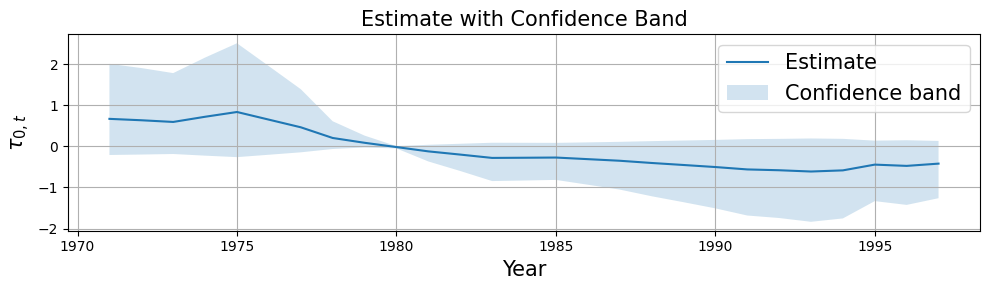

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & 1971 & 1972 & 1973 & 1974 & 1975 & 1976 & 1977 & 1978 & 1979 & 1980 & 1981 & 1982 & 1983 & 1984 & 1985 & 1986 & 1987 & 1988 & 1989 & 1990 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & 0.683 & 0.648 & 0.606 & 0.770 & 0.921 & 0.726 & 0.534 & 0.237 & 0.093 & -0.023 & -0.147 & -0.215 & -0.292 & -0.257 & -0.227 & -0.265 & -0.301 & -0.339 & -0.383 & -0.428 & -0.472 & -0.548 & -0.628 & -0.620 & -0.438 & -0.467 & -0.399 \\
Lower bound ($\underline{\tau}_{0, t}$) & -0.241 & -0.229 & -0.214 & -0.272 & -0.326 & -0.257 & -0.189 & -0.084 & -0.033 & -0.070 & -0.442 & -0.644 & -0.877 & -0.770 & -0.680 & -0.794 & -0.903 & -1.017 & -1.150 & -1.284 & -1.417 & -1.643 & -1.885 & -1.861 & -1.314 & -1.402 & -1.198 \\
Upper bound ($\overline{\tau}_{0, t}$) & 2.049 & 1.943 & 1.818 & 2.311 & 2.762 & 2.179 & 1.602 & 0.711 & 0.280 & 0.008 & 0.052 & 0.076 & 0.103 & 0.091 & 0.080 & 0.094 & 0.106 & 0.120 & 

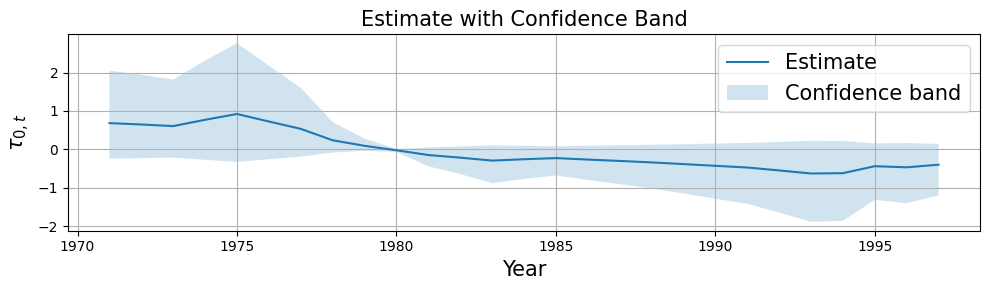

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & 1971 & 1972 & 1973 & 1974 & 1975 & 1976 & 1977 & 1978 & 1979 & 1980 & 1981 & 1982 & 1983 & 1984 & 1985 & 1986 & 1987 & 1988 & 1989 & 1990 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & 0.733 & 0.703 & 0.665 & 0.832 & 0.984 & 0.782 & 0.583 & 0.276 & 0.129 & 0.015 & -0.106 & -0.178 & -0.261 & -0.225 & -0.195 & -0.230 & -0.264 & -0.302 & -0.348 & -0.400 & -0.450 & -0.528 & -0.611 & -0.609 & -0.427 & -0.459 & -0.392 \\
Lower bound ($\underline{\tau}_{0, t}$) & -0.230 & -0.220 & -0.208 & -0.260 & -0.308 & -0.245 & -0.182 & -0.087 & -0.041 & -0.005 & -0.318 & -0.535 & -0.783 & -0.675 & -0.585 & -0.689 & -0.791 & -0.906 & -1.043 & -1.200 & -1.351 & -1.584 & -1.832 & -1.826 & -1.282 & -1.378 & -1.175 \\
Upper bound ($\overline{\tau}_{0, t}$) & 2.199 & 2.108 & 1.996 & 2.495 & 2.952 & 2.347 & 1.748 & 0.829 & 0.388 & 0.046 & 0.033 & 0.056 & 0.082 & 0.070 & 0.061 & 0.072 & 0.083 & 0.095 & 0

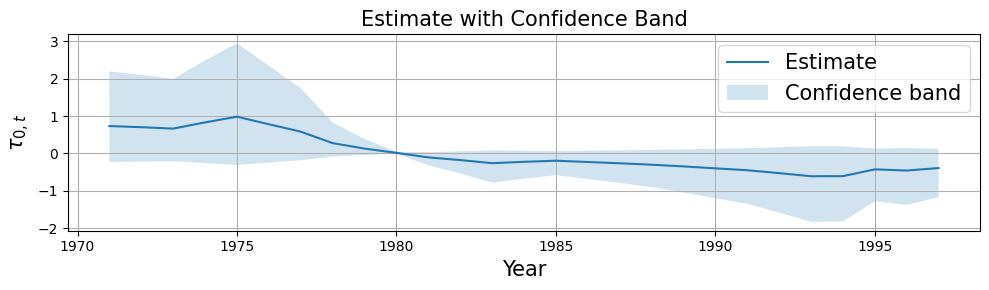

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & 1971 & 1972 & 1973 & 1974 & 1975 & 1976 & 1977 & 1978 & 1979 & 1980 & 1981 & 1982 & 1983 & 1984 & 1985 & 1986 & 1987 & 1988 & 1989 & 1990 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & 0.844 & 0.825 & 0.796 & 0.934 & 1.059 & 0.849 & 0.638 & 0.342 & 0.214 & 0.117 & 0.019 & -0.072 & -0.170 & -0.163 & -0.158 & -0.184 & -0.213 & -0.265 & -0.316 & -0.390 & -0.467 & -0.504 & -0.551 & -0.540 & -0.396 & -0.435 & -0.378 \\
Lower bound ($\underline{\tau}_{0, t}$) & -0.230 & -0.225 & -0.217 & -0.255 & -0.289 & -0.231 & -0.174 & -0.093 & -0.058 & -0.032 & -0.005 & -0.217 & -0.509 & -0.488 & -0.474 & -0.552 & -0.639 & -0.794 & -0.947 & -1.170 & -1.400 & -1.512 & -1.652 & -1.620 & -1.187 & -1.304 & -1.134 \\
Upper bound ($\overline{\tau}_{0, t}$) & 2.531 & 2.474 & 2.389 & 2.801 & 3.176 & 2.546 & 1.914 & 1.025 & 0.641 & 0.352 & 0.056 & 0.020 & 0.046 & 0.044 & 0.043 & 0.050 & 0.058 & 0.072 & 0.

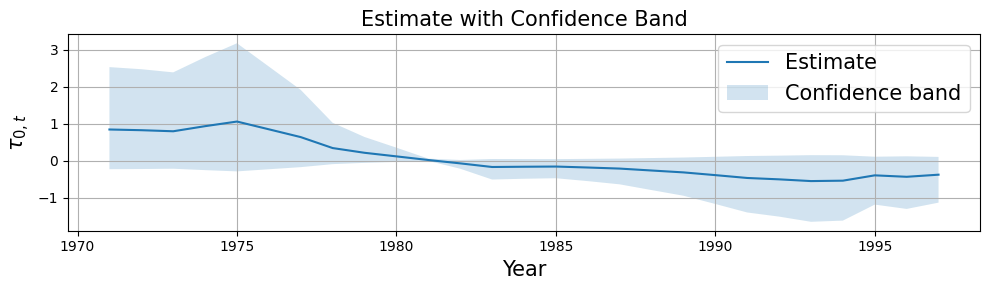

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & 1971 & 1972 & 1973 & 1974 & 1975 & 1976 & 1977 & 1978 & 1979 & 1980 & 1981 & 1982 & 1983 & 1984 & 1985 & 1986 & 1987 & 1988 & 1989 & 1990 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & 1.126 & 1.134 & 1.130 & 1.199 & 1.260 & 1.028 & 0.788 & 0.512 & 0.427 & 0.374 & 0.330 & 0.193 & 0.059 & -0.003 & -0.058 & -0.062 & -0.079 & -0.162 & -0.227 & -0.355 & -0.497 & -0.440 & -0.402 & -0.373 & -0.317 & -0.373 & -0.343 \\
Lower bound ($\underline{\tau}_{0, t}$) & -0.716 & -0.722 & -0.719 & -0.763 & -0.802 & -0.654 & -0.501 & -0.326 & -0.272 & -0.238 & -0.210 & -0.123 & -0.037 & -0.009 & -0.174 & -0.187 & -0.237 & -0.487 & -0.680 & -1.066 & -1.490 & -1.319 & -1.206 & -1.120 & -0.950 & -1.120 & -1.029 \\
Upper bound ($\overline{\tau}_{0, t}$) & 3.377 & 3.403 & 3.389 & 3.598 & 3.781 & 3.084 & 2.364 & 1.536 & 1.281 & 1.121 & 0.991 & 0.579 & 0.176 & 0.002 & 0.037 & 0.040 & 0.050 & 0.103 & 0.14

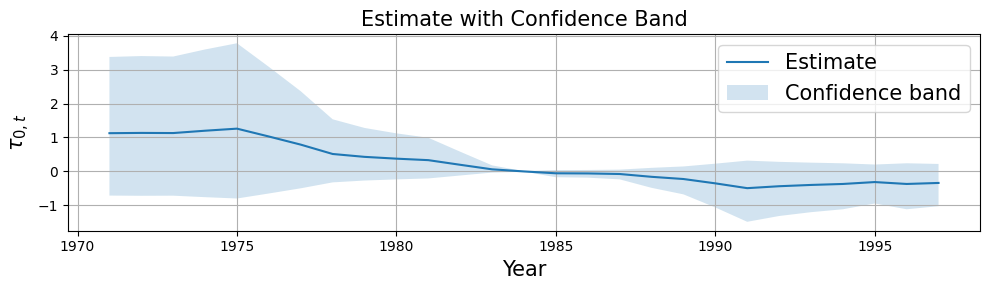

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & 1971 & 1972 & 1973 & 1974 & 1975 & 1976 & 1977 & 1978 & 1979 & 1980 & 1981 & 1982 & 1983 & 1984 & 1985 & 1986 & 1987 & 1988 & 1989 & 1990 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & 1.111 & 1.118 & 1.112 & 1.171 & 1.223 & 0.995 & 0.759 & 0.495 & 0.417 & 0.367 & 0.328 & 0.190 & 0.056 & -0.014 & -0.077 & -0.082 & -0.099 & -0.186 & -0.251 & -0.378 & -0.521 & -0.451 & -0.401 & -0.364 & -0.317 & -0.374 & -0.346 \\
Lower bound ($\underline{\tau}_{0, t}$) & -0.707 & -0.712 & -0.708 & -0.745 & -0.778 & -0.633 & -0.483 & -0.315 & -0.266 & -0.233 & -0.208 & -0.121 & -0.036 & -0.043 & -0.230 & -0.245 & -0.298 & -0.558 & -0.752 & -1.135 & -1.564 & -1.353 & -1.203 & -1.093 & -0.951 & -1.121 & -1.039 \\
Upper bound ($\overline{\tau}_{0, t}$) & 3.333 & 3.355 & 3.336 & 3.514 & 3.669 & 2.985 & 2.276 & 1.484 & 1.252 & 1.100 & 0.983 & 0.569 & 0.168 & 0.009 & 0.049 & 0.052 & 0.063 & 0.118 & 0.15

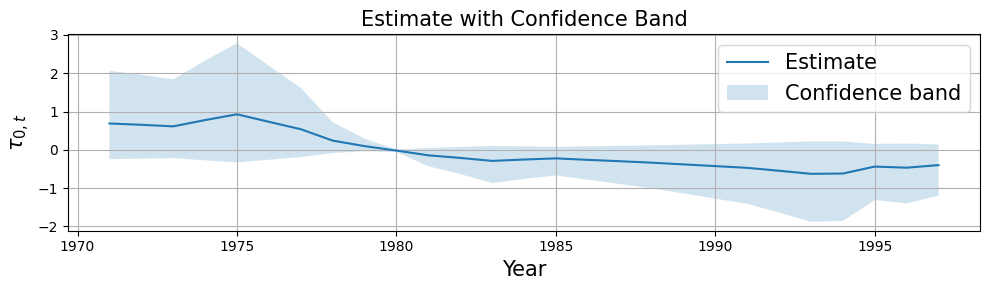

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & 1971 & 1972 & 1973 & 1974 & 1975 & 1976 & 1977 & 1978 & 1979 & 1980 & 1981 & 1982 & 1983 & 1984 & 1985 & 1986 & 1987 & 1988 & 1989 & 1990 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & 1.367 & 1.379 & 1.378 & 1.538 & 1.682 & 1.426 & 1.170 & 0.818 & 0.680 & 0.618 & 0.555 & 0.434 & 0.309 & 0.314 & 0.315 & 0.328 & 0.333 & 0.287 & 0.242 & 0.147 & 0.052 & 0.006 & -0.050 & -0.055 & 0.096 & 0.059 & 0.136 \\
Lower bound ($\underline{\tau}_{0, t}$) & -1.367 & -1.379 & -1.378 & -1.538 & -1.682 & -1.426 & -1.170 & -0.818 & -0.680 & -0.618 & -0.555 & -0.434 & -0.309 & -0.314 & -0.315 & -0.328 & -0.333 & -0.287 & -0.242 & -0.147 & -0.052 & -0.006 & -0.035 & -0.038 & -0.096 & -0.059 & -0.136 \\
Upper bound ($\overline{\tau}_{0, t}$) & 0.952 & 0.961 & 0.961 & 1.072 & 1.172 & 0.994 & 0.816 & 0.570 & 0.474 & 0.431 & 0.387 & 0.303 & 0.215 & 0.219 & 0.220 & 0.228 & 0.232 & 0.200 & 0.169 & 0.102 & 

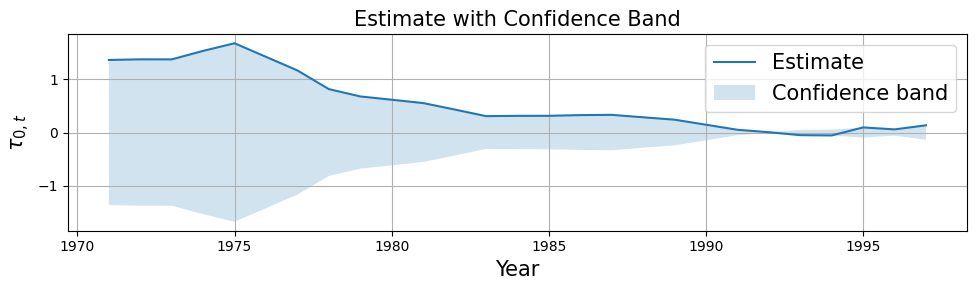

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & 1971 & 1972 & 1973 & 1974 & 1975 & 1976 & 1977 & 1978 & 1979 & 1980 & 1981 & 1982 & 1983 & 1984 & 1985 & 1986 & 1987 & 1988 & 1989 & 1990 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & -0.138 & -0.216 & -0.321 & -0.424 & -0.241 & -0.065 & -0.206 & -0.340 & -0.553 & -0.662 & -0.869 & -1.080 & -1.137 & -1.199 & -1.238 & -1.281 & -1.403 & -1.498 & -1.493 & -1.479 & -1.397 & -1.351 & -1.317 & -1.291 & -1.288 & -1.134 & -1.105 \\
Lower bound ($\underline{\tau}_{0, t}$) & 0.011 & -0.055 & -0.160 & -0.264 & -0.094 & 0.069 & -0.058 & -0.181 & -0.379 & -0.486 & -0.680 & -0.879 & -0.921 & -0.968 & -0.990 & -1.014 & -1.128 & -1.218 & -1.222 & -1.217 & -1.139 & -1.092 & -1.077 & -1.070 & -1.044 & -0.879 & -0.856 \\
Upper bound ($\overline{\tau}_{0, t}$) & -0.481 & -0.593 & -0.725 & -0.855 & -0.636 & -0.422 & -0.574 & -0.716 & -0.955 & -1.056 & -1.319 & -1.580 & -1.664 & -1.754 & -1.872 & -2

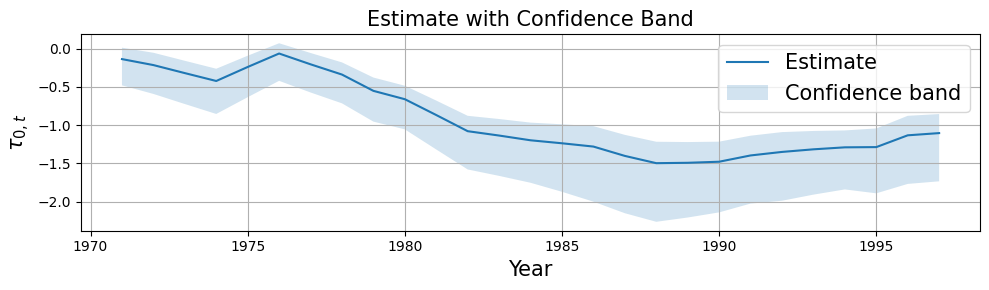

In [29]:
result = np.load("result/basque_res.npy")

year_list = [1971 + i for i in range(27)]

plot_method_indices = [0, 1, 2, 3, 4, 6, 7, 8]  # match paper figure panel selection

for j in range(len(result)):
    result_temp = pd.DataFrame(result[j]).round(3)
    result_temp.columns = year_list
    result_temp = result_temp.T
    result_temp.columns = ["Estimate ($\\widehat{\\tau}_{0, t}$)", "Lower bound ($\\underline{\\tau}_{0, t}$)", "Upper bound ($\\overline{\\tau}_{0, t}$)"]
    result_temp = result_temp.T
    print(result_temp.to_latex(float_format="{:.3f}".format))
    
    years = result_temp.columns.astype(int)
    estimate = result_temp.loc[r"Estimate ($\widehat{\tau}_{0, t}$)"].values
    lower = result_temp.loc[r"Lower bound ($\underline{\tau}_{0, t}$)"].values
    upper = result_temp.loc[r"Upper bound ($\overline{\tau}_{0, t}$)"].values
    
    if j == 8:
        lower0 = lower.copy()
        lower = upper
        upper = lower0
    
    print(j)
    print(lower)
    print(upper)

    
    lower[lower > estimate] = estimate[lower > estimate]
    upper[upper < estimate] = estimate[upper < estimate]

    if j in plot_method_indices:
        # Plot
        plt.figure(figsize=(10, 3))
        plt.plot(years, estimate, label="Estimate")
        plt.fill_between(years, lower, upper, alpha=0.2, label="Confidence band")
        plt.xlabel("Year", fontsize=15)
        plt.ylabel(r"$\tau_{0, t}$", fontsize=15)
        plt.title("Estimate with Confidence Band", fontsize=15)
        plt.legend(fontsize=15)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [37]:
result = np.load("result/basque_res.npy")

year_list = [1971 + i for i in range(27)]

plot_method_indices = [0, 1, 2, 3, 4, 6, 7, 8]  # match paper figure panel selection

for j in range(len(result)):
    result_temp = pd.DataFrame(result[j]).round(3)
    result_temp.columns = year_list
    result_temp = result_temp.T
    result_temp.columns = ["Estimate ($\\widehat{\\tau}_{0, t}$)", "Lower bound ($\\underline{\\tau}_{0, t}$)", "Upper bound ($\\overline{\\tau}_{0, t}$)"]
    result_temp = result_temp.T
    print(result_temp.to_latex(float_format="{:.3f}".format))
    
    years = result_temp.columns.astype(int)
    estimate = result_temp.loc[r"Estimate ($\widehat{\tau}_{0, t}$)"].values
    lower = result_temp.loc[r"Lower bound ($\underline{\tau}_{0, t}$)"].values
    upper = result_temp.loc[r"Upper bound ($\overline{\tau}_{0, t}$)"].values

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & 1971 & 1972 & 1973 & 1974 & 1975 & 1976 & 1977 & 1978 & 1979 & 1980 & 1981 & 1982 & 1983 & 1984 & 1985 & 1986 & 1987 & 1988 & 1989 & 1990 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & 0.669 & 0.635 & 0.594 & 0.720 & 0.836 & 0.650 & 0.464 & 0.204 & 0.087 & -0.017 & -0.122 & -0.200 & -0.281 & -0.277 & -0.272 & -0.311 & -0.350 & -0.404 & -0.453 & -0.503 & -0.561 & -0.581 & -0.612 & -0.584 & -0.444 & -0.475 & -0.420 \\
Lower bound ($\underline{\tau}_{0, t}$) & -0.210 & -0.199 & -0.186 & -0.226 & -0.262 & -0.204 & -0.145 & -0.064 & -0.027 & -0.050 & -0.367 & -0.599 & -0.844 & -0.831 & -0.816 & -0.933 & -1.051 & -1.213 & -1.358 & -1.508 & -1.682 & -1.743 & -1.835 & -1.753 & -1.332 & -1.424 & -1.261 \\
Upper bound ($\overline{\tau}_{0, t}$) & 2.007 & 1.905 & 1.782 & 2.160 & 2.508 & 1.951 & 1.391 & 0.611 & 0.262 & 0.005 & 0.038 & 0.063 & 0.088 & 0.087 & 0.085 & 0.097 & 0.110 & 0.127 & 

\begin{tabular}{lrrrrrrrrrrrrr}
\toprule
 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 & 1998 & 1999 & 2000 & 2001 & 2002 & 2003 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & 327.880 & 228.558 & -418.809 & -724.432 & -815.110 & -974.383 & -1372.114 & -1235.992 & -1161.941 & -1571.169 & -1579.920 & -1769.058 & -2140.223 \\
Lower bound ($\underline{\tau}_{0, t}$) & 202.027 & 140.829 & -714.936 & -1236.657 & -1391.451 & -1663.340 & -2342.296 & -2109.926 & -1983.516 & -2682.097 & -2697.035 & -3019.907 & -3653.512 \\
Upper bound ($\overline{\tau}_{0, t}$) & 559.715 & 390.165 & -258.054 & -446.367 & -502.240 & -600.377 & -845.444 & -761.571 & -715.944 & -968.094 & -973.486 & -1090.026 & -1318.723 \\
\bottomrule
\end{tabular}



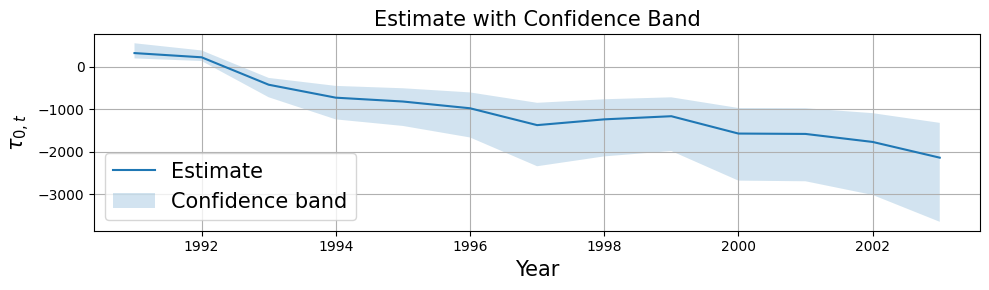

\begin{tabular}{lrrrrrrrrrrrrr}
\toprule
 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 & 1998 & 1999 & 2000 & 2001 & 2002 & 2003 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & 445.970 & 341.007 & -307.692 & -612.796 & -710.657 & -896.374 & -1274.747 & -1114.977 & -1045.510 & -1450.164 & -1463.503 & -1624.141 & -1995.589 \\
Lower bound ($\underline{\tau}_{0, t}$) & 274.789 & 210.115 & -649.573 & -1293.680 & -1500.275 & -1892.345 & -2691.132 & -2353.840 & -2207.188 & -3061.457 & -3089.617 & -3428.742 & -4212.909 \\
Upper bound ($\overline{\tau}_{0, t}$) & 941.492 & 719.904 & -189.588 & -377.581 & -437.879 & -552.311 & -785.450 & -687.006 & -644.203 & -893.535 & -901.754 & -1000.733 & -1229.605 \\
\bottomrule
\end{tabular}



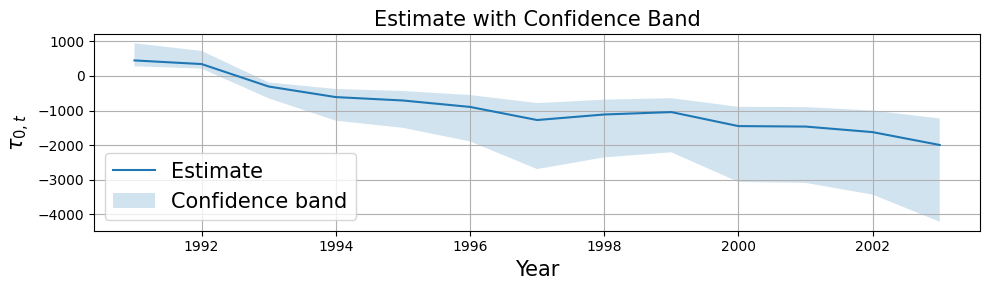

\begin{tabular}{lrrrrrrrrrrrrr}
\toprule
 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 & 1998 & 1999 & 2000 & 2001 & 2002 & 2003 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & 454.533 & 347.786 & -297.835 & -605.163 & -703.606 & -888.683 & -1261.814 & -1109.264 & -1049.019 & -1458.731 & -1470.792 & -1635.784 & -2006.213 \\
Lower bound ($\underline{\tau}_{0, t}$) & 224.971 & 172.137 & -676.897 & -1375.372 & -1599.105 & -2019.734 & -2867.760 & -2521.053 & -2384.135 & -3315.299 & -3342.708 & -3717.691 & -4559.576 \\
Upper bound ($\overline{\tau}_{0, t}$) & 1033.029 & 790.423 & -147.413 & -299.525 & -348.249 & -439.853 & -624.534 & -549.029 & -519.212 & -721.998 & -727.968 & -809.631 & -992.974 \\
\bottomrule
\end{tabular}



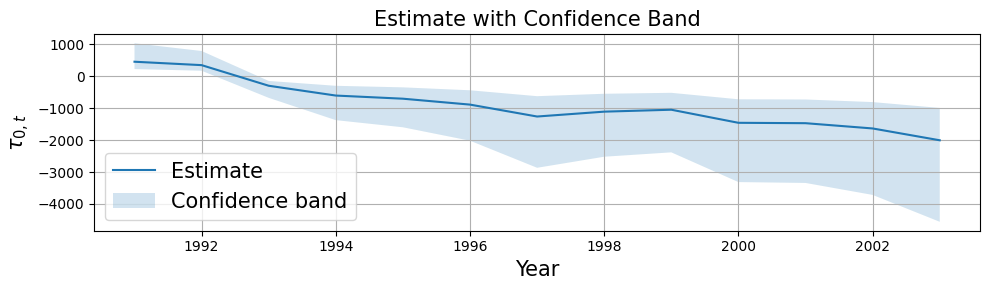

\begin{tabular}{lrrrrrrrrrrrrr}
\toprule
 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 & 1998 & 1999 & 2000 & 2001 & 2002 & 2003 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & 496.735 & 362.964 & -330.006 & -673.647 & -801.127 & -1041.570 & -1461.328 & -1327.563 & -1308.178 & -1710.521 & -1808.892 & -1910.430 & -2305.259 \\
Lower bound ($\underline{\tau}_{0, t}$) & 145.508 & 106.323 & -776.680 & -1585.451 & -1885.482 & -2451.372 & -3439.287 & -3124.467 & -3078.843 & -4025.771 & -4257.291 & -4496.265 & -5425.507 \\
Upper bound ($\overline{\tau}_{0, t}$) & 1169.083 & 854.249 & -96.668 & -197.331 & -234.674 & -305.106 & -428.066 & -388.882 & -383.204 & -501.062 & -529.877 & -559.621 & -675.278 \\
\bottomrule
\end{tabular}



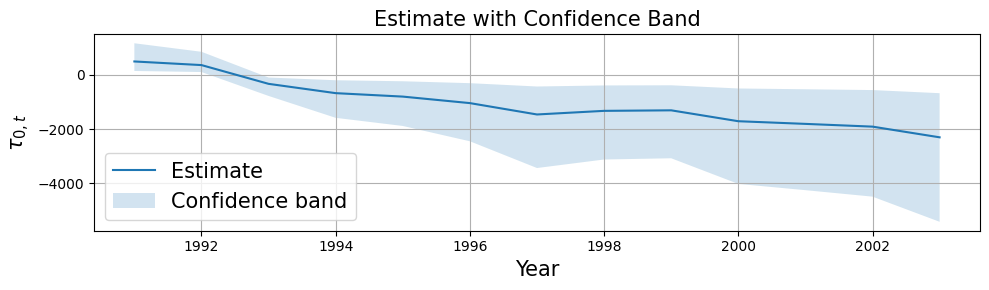

\begin{tabular}{lrrrrrrrrrrrrr}
\toprule
 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 & 1998 & 1999 & 2000 & 2001 & 2002 & 2003 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & 841.486 & 691.160 & -121.062 & -579.295 & -781.670 & -991.560 & -1654.087 & -1699.780 & -1822.579 & -2358.659 & -2690.635 & -2827.447 & -3223.693 \\
Lower bound ($\underline{\tau}_{0, t}$) & 144.498 & 118.684 & -363.185 & -1737.885 & -2345.010 & -2974.680 & -4962.262 & -5099.340 & -5467.738 & -7075.977 & -8071.906 & -8482.342 & -9671.078 \\
Upper bound ($\overline{\tau}_{0, t}$) & 2524.457 & 2073.479 & -20.788 & -99.475 & -134.226 & -170.268 & -284.035 & -291.881 & -312.968 & -405.022 & -462.028 & -485.521 & -553.563 \\
\bottomrule
\end{tabular}



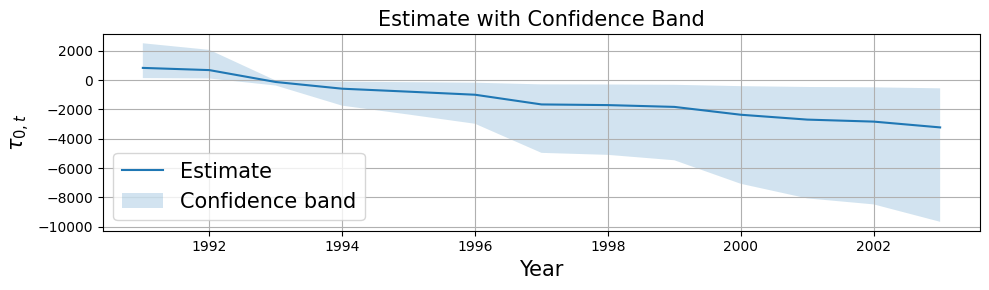

\begin{tabular}{lrrrrrrrrrrrrr}
\toprule
 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 & 1998 & 1999 & 2000 & 2001 & 2002 & 2003 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & 259.005 & 94.520 & -578.231 & -972.452 & -1095.005 & -1275.892 & -1679.361 & -1729.888 & -1880.311 & -2348.777 & -2374.989 & -2612.189 & -3034.105 \\
Lower bound ($\underline{\tau}_{0, t}$) & 107.265 & 39.145 & -1290.798 & -2170.827 & -2444.405 & -2848.203 & -3748.877 & -3861.669 & -4197.463 & -5243.230 & -5301.743 & -5831.250 & -6773.102 \\
Upper bound ($\overline{\tau}_{0, t}$) & 578.183 & 211.000 & -239.469 & -402.733 & -453.487 & -528.400 & -695.493 & -716.418 & -778.715 & -972.726 & -983.581 & -1081.816 & -1256.548 \\
\bottomrule
\end{tabular}



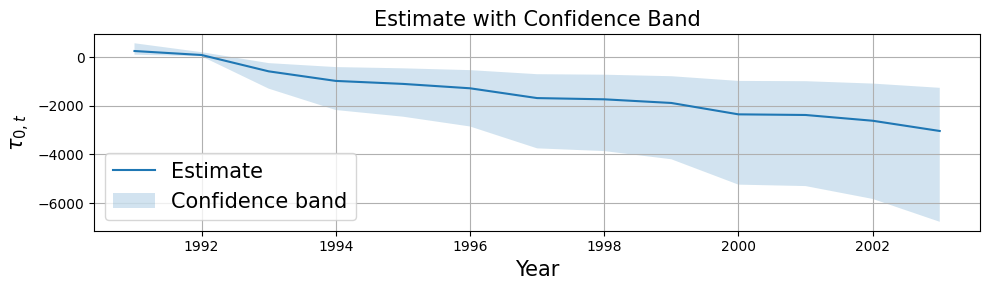

\begin{tabular}{lrrrrrrrrrrrrr}
\toprule
 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 & 1998 & 1999 & 2000 & 2001 & 2002 & 2003 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & 953.663 & 834.641 & 40.099 & -465.885 & -670.172 & -803.381 & -1508.747 & -1577.073 & -1737.511 & -2407.415 & -2802.246 & -2936.485 & -3248.218 \\
Lower bound ($\underline{\tau}_{0, t}$) & 202.292 & 177.045 & 8.506 & -1397.656 & -2010.516 & -2410.143 & -4526.242 & -4731.218 & -5212.533 & -7222.244 & -8406.737 & -8809.456 & -9744.655 \\
Upper bound ($\overline{\tau}_{0, t}$) & 2860.988 & 2503.923 & 120.296 & -98.824 & -142.158 & -170.414 & -320.037 & -334.531 & -368.563 & -510.664 & -594.416 & -622.891 & -689.016 \\
\bottomrule
\end{tabular}



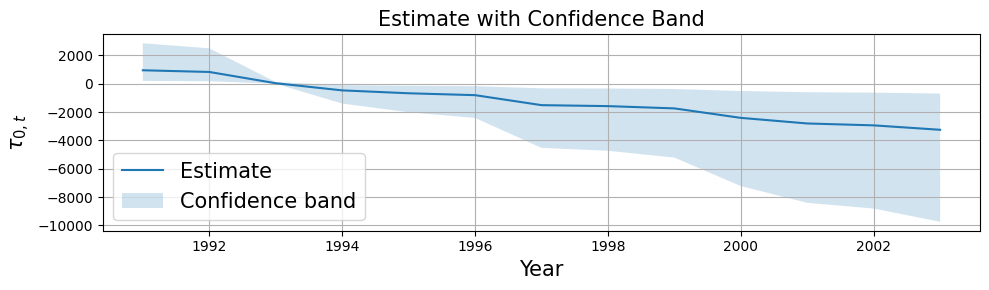

\begin{tabular}{lrrrrrrrrrrrrr}
\toprule
 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 & 1998 & 1999 & 2000 & 2001 & 2002 & 2003 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & 501.801 & 325.127 & -439.827 & -904.846 & -1109.224 & -1316.447 & -1848.305 & -2119.048 & -2313.993 & -2756.768 & -3075.527 & -3167.449 & -3465.177 \\
Lower bound ($\underline{\tau}_{0, t}$) & 1673.798 & 857.345 & 155.975 & -203.319 & 56.892 & -140.759 & -592.654 & -759.429 & -946.702 & 210.827 & 900.632 & -907.722 & -1186.747 \\
Upper bound ($\overline{\tau}_{0, t}$) & -610.689 & -214.333 & -1032.809 & -1567.552 & -2246.457 & -2198.569 & -2918.746 & -3439.695 & -3480.269 & -4590.658 & -5533.014 & -4855.540 & -5136.086 \\
\bottomrule
\end{tabular}



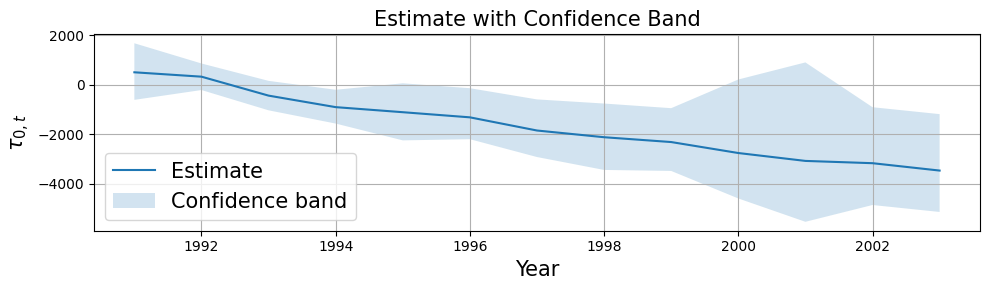

In [33]:
result = np.load("result/germany_res.npy")

year_list = [1991 + i for i in range(13)]

plot_method_indices = [0, 1, 2, 3, 4, 6, 7, 8]  # match paper figure panel selection

for j in range(len(result)):
    result_temp = pd.DataFrame(result[j]).round(3)
    result_temp.columns = year_list
    result_temp = result_temp.T
    result_temp.columns = ["Estimate ($\\widehat{\\tau}_{0, t}$)", "Lower bound ($\\underline{\\tau}_{0, t}$)", "Upper bound ($\\overline{\\tau}_{0, t}$)"]
    result_temp = result_temp.T
    
    years = result_temp.columns.astype(int)
    estimate = result_temp.loc[r"Estimate ($\widehat{\tau}_{0, t}$)"].values
    lower = result_temp.loc[r"Lower bound ($\underline{\tau}_{0, t}$)"].values
    upper = result_temp.loc[r"Upper bound ($\overline{\tau}_{0, t}$)"].values

    if j in plot_method_indices:
        print(result_temp.to_latex(float_format="{:.3f}".format))
        # Plot
        plt.figure(figsize=(10, 3))
        plt.plot(years, estimate, label="Estimate")
        plt.fill_between(years, lower, upper, alpha=0.2, label="Confidence band")
        plt.xlabel("Year", fontsize=15)
        plt.ylabel(r"$\tau_{0, t}$", fontsize=15)
        plt.title("Estimate with Confidence Band", fontsize=15)
        plt.legend(fontsize=15)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [35]:
result = np.load("result/germany_res.npy")

year_list = [1991 + i for i in range(13)]

plot_method_indices = [0, 1, 2, 3, 4, 6, 7, 8]  # match paper figure panel selection

for j in range(len(result)):
    result_temp = pd.DataFrame(result[j]).round(3)
    result_temp.columns = year_list
    result_temp = result_temp.T
    result_temp.columns = ["Estimate ($\\widehat{\\tau}_{0, t}$)", "Lower bound ($\\underline{\\tau}_{0, t}$)", "Upper bound ($\\overline{\\tau}_{0, t}$)"]
    result_temp = result_temp.T
    
    years = result_temp.columns.astype(int)
    estimate = result_temp.loc[r"Estimate ($\widehat{\tau}_{0, t}$)"].values
    lower = result_temp.loc[r"Lower bound ($\underline{\tau}_{0, t}$)"].values
    upper = result_temp.loc[r"Upper bound ($\overline{\tau}_{0, t}$)"].values

    print(result_temp.to_latex(float_format="{:.3f}".format))

\begin{tabular}{lrrrrrrrrrrrrr}
\toprule
 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 & 1998 & 1999 & 2000 & 2001 & 2002 & 2003 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & 327.880 & 228.558 & -418.809 & -724.432 & -815.110 & -974.383 & -1372.114 & -1235.992 & -1161.941 & -1571.169 & -1579.920 & -1769.058 & -2140.223 \\
Lower bound ($\underline{\tau}_{0, t}$) & 202.027 & 140.829 & -714.936 & -1236.657 & -1391.451 & -1663.340 & -2342.296 & -2109.926 & -1983.516 & -2682.097 & -2697.035 & -3019.907 & -3653.512 \\
Upper bound ($\overline{\tau}_{0, t}$) & 559.715 & 390.165 & -258.054 & -446.367 & -502.240 & -600.377 & -845.444 & -761.571 & -715.944 & -968.094 & -973.486 & -1090.026 & -1318.723 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrrrrrrrrrrrrr}
\toprule
 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 & 1998 & 1999 & 2000 & 2001 & 2002 & 2003 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & 445.970 & 341.007 & -307.692 & -612.796 & -710.657 & -896.374 & -1274.747 & -1114

\begin{tabular}{lrrrrrrrrrrr}
\toprule
 & 1990 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 & 1998 & 1999 & 2000 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & -14.348 & -22.565 & -22.348 & -25.688 & -29.688 & -31.646 & -31.870 & -32.007 & -32.452 & -34.963 & -36.109 \\
Lower bound ($\underline{\tau}_{0, t}$) & -16.957 & -26.668 & -26.411 & -30.359 & -35.086 & -37.400 & -37.665 & -37.826 & -38.353 & -41.320 & -42.674 \\
Upper bound ($\overline{\tau}_{0, t}$) & 5.073 & 7.977 & 7.901 & 9.082 & 10.496 & 11.188 & 11.267 & 11.315 & 11.473 & 12.361 & 12.766 \\
\bottomrule
\end{tabular}



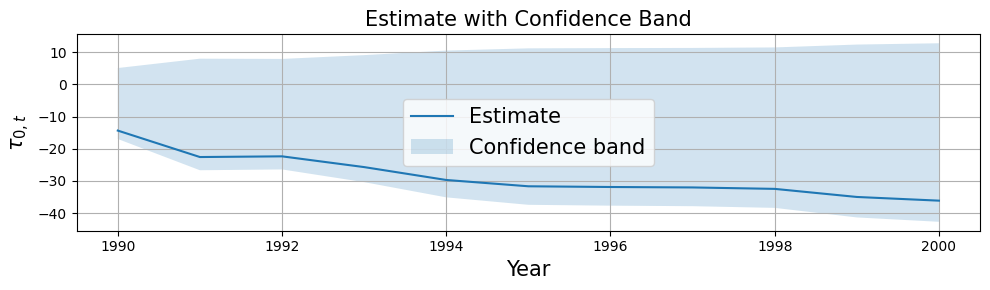

\begin{tabular}{lrrrrrrrrrrr}
\toprule
 & 1990 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 & 1998 & 1999 & 2000 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & -14.162 & -22.355 & -22.181 & -25.662 & -29.757 & -31.655 & -31.749 & -32.075 & -32.421 & -34.761 & -35.743 \\
Lower bound ($\underline{\tau}_{0, t}$) & -19.598 & -30.936 & -30.695 & -35.512 & -41.179 & -43.806 & -43.936 & -44.387 & -44.865 & -48.103 & -49.462 \\
Upper bound ($\overline{\tau}_{0, t}$) & 5.007 & 7.903 & 7.842 & 9.072 & 10.520 & 11.191 & 11.225 & 11.340 & 11.462 & 12.289 & 12.636 \\
\bottomrule
\end{tabular}



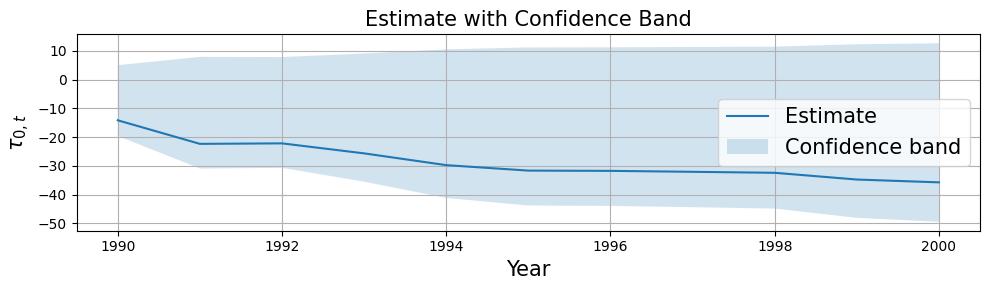

\begin{tabular}{lrrrrrrrrrrr}
\toprule
 & 1990 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 & 1998 & 1999 & 2000 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & -16.070 & -25.074 & -25.344 & -28.937 & -33.229 & -35.489 & -35.507 & -36.330 & -36.699 & -38.613 & -39.638 \\
Lower bound ($\underline{\tau}_{0, t}$) & -20.290 & -31.659 & -32.000 & -36.536 & -41.955 & -44.810 & -44.832 & -45.871 & -46.337 & -48.753 & -50.048 \\
Upper bound ($\overline{\tau}_{0, t}$) & 5.681 & 8.865 & 8.960 & 10.230 & 11.748 & 12.547 & 12.553 & 12.844 & 12.974 & 13.651 & 14.014 \\
\bottomrule
\end{tabular}



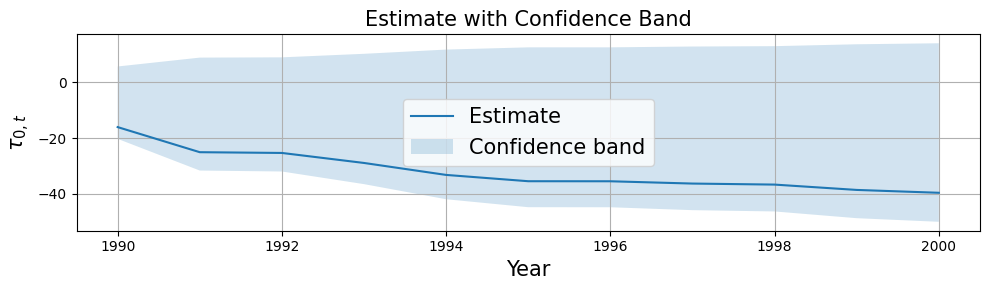

\begin{tabular}{lrrrrrrrrrrr}
\toprule
 & 1990 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 & 1998 & 1999 & 2000 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & -16.077 & -25.082 & -25.347 & -28.945 & -33.232 & -35.491 & -35.514 & -36.343 & -36.716 & -38.621 & -39.645 \\
Lower bound ($\underline{\tau}_{0, t}$) & -24.196 & -37.749 & -38.148 & -43.563 & -50.016 & -53.416 & -53.450 & -54.698 & -55.260 & -58.126 & -59.668 \\
Upper bound ($\overline{\tau}_{0, t}$) & 6.333 & 9.881 & 9.985 & 11.402 & 13.091 & 13.981 & 13.990 & 14.317 & 14.464 & 15.214 & 15.618 \\
\bottomrule
\end{tabular}



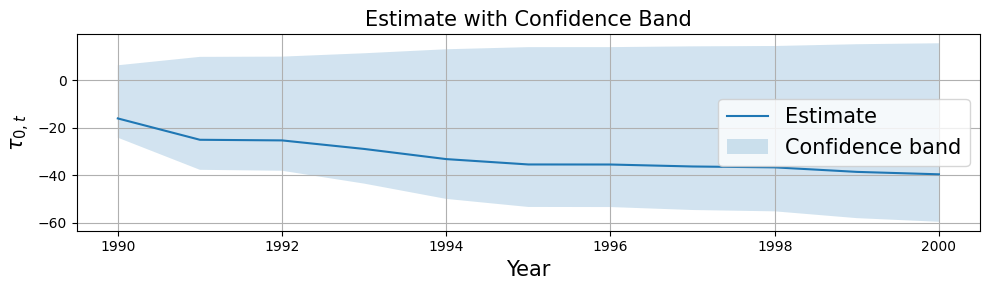

\begin{tabular}{lrrrrrrrrrrr}
\toprule
 & 1990 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 & 1998 & 1999 & 2000 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & -19.114 & -28.076 & -28.480 & -31.898 & -36.305 & -38.845 & -38.632 & -39.511 & -40.088 & -41.983 & -42.948 \\
Lower bound ($\underline{\tau}_{0, t}$) & -24.906 & -36.584 & -37.111 & -41.564 & -47.306 & -50.616 & -50.339 & -51.484 & -52.236 & -54.705 & -55.963 \\
Upper bound ($\overline{\tau}_{0, t}$) & 6.757 & 9.926 & 10.069 & 11.277 & 12.835 & 13.733 & 13.658 & 13.968 & 14.173 & 14.842 & 15.184 \\
\bottomrule
\end{tabular}



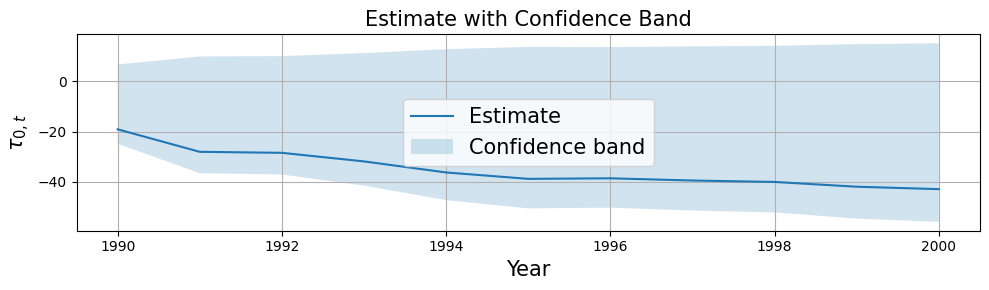

\begin{tabular}{lrrrrrrrrrrr}
\toprule
 & 1990 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 & 1998 & 1999 & 2000 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & -21.245 & -29.901 & -30.293 & -33.607 & -37.968 & -40.632 & -40.331 & -41.157 & -41.945 & -43.863 & -44.732 \\
Lower bound ($\underline{\tau}_{0, t}$) & -25.108 & -35.337 & -35.800 & -39.717 & -44.871 & -48.019 & -47.664 & -48.640 & -49.572 & -51.838 & -52.865 \\
Upper bound ($\overline{\tau}_{0, t}$) & 8.369 & 11.779 & 11.933 & 13.239 & 14.957 & 16.006 & 15.888 & 16.213 & 16.524 & 17.279 & 17.622 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrrrrrrrrrrr}
\toprule
 & 1990 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 & 1998 & 1999 & 2000 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & -10.644 & -18.752 & -19.048 & -23.708 & -27.834 & -29.551 & -30.076 & -31.136 & -30.791 & -33.061 & -32.690 \\
Lower bound ($\underline{\tau}_{0, t}$) & -26.341 & -46.406 & -47.138 & -58.671 & -68.882 & -73.131 & -74.430 & -77.055 & -76.

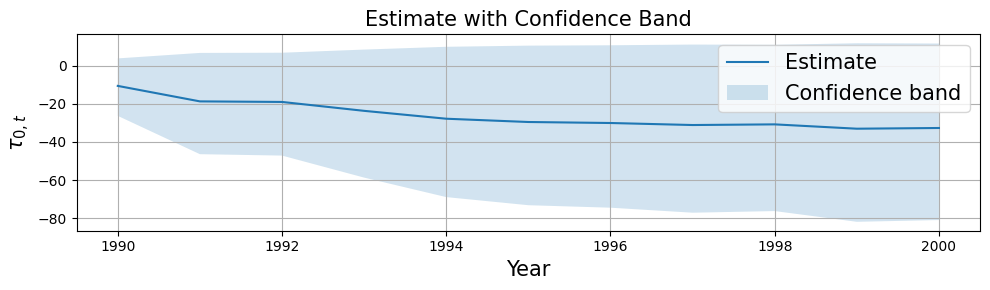

\begin{tabular}{lrrrrrrrrrrr}
\toprule
 & 1990 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 & 1998 & 1999 & 2000 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & -10.403 & -18.998 & -19.634 & -24.119 & -29.899 & -30.819 & -31.128 & -32.149 & -32.234 & -34.680 & -34.051 \\
Lower bound ($\underline{\tau}_{0, t}$) & -24.485 & -44.713 & -46.209 & -56.764 & -70.369 & -72.533 & -73.261 & -75.664 & -75.864 & -81.621 & -80.141 \\
Upper bound ($\overline{\tau}_{0, t}$) & 2.837 & 5.181 & 5.355 & 6.578 & 8.154 & 8.405 & 8.489 & 8.768 & 8.791 & 9.458 & 9.287 \\
\bottomrule
\end{tabular}



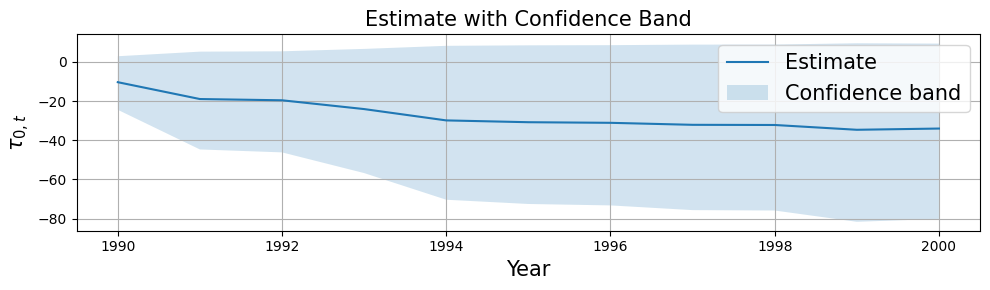

\begin{tabular}{lrrrrrrrrrrr}
\toprule
 & 1990 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 & 1998 & 1999 & 2000 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & -9.659 & -10.875 & -13.460 & -14.301 & -17.633 & -21.859 & -22.760 & -23.583 & -25.117 & -23.206 & -27.228 \\
Lower bound ($\underline{\tau}_{0, t}$) & -3.876 & -4.886 & -7.346 & -8.138 & -8.889 & -13.372 & -16.258 & -14.058 & -15.537 & -13.986 & -16.757 \\
Upper bound ($\overline{\tau}_{0, t}$) & -14.468 & -16.782 & -18.073 & -18.834 & -20.924 & -26.263 & -27.990 & -28.120 & -31.839 & -30.213 & -31.807 \\
\bottomrule
\end{tabular}



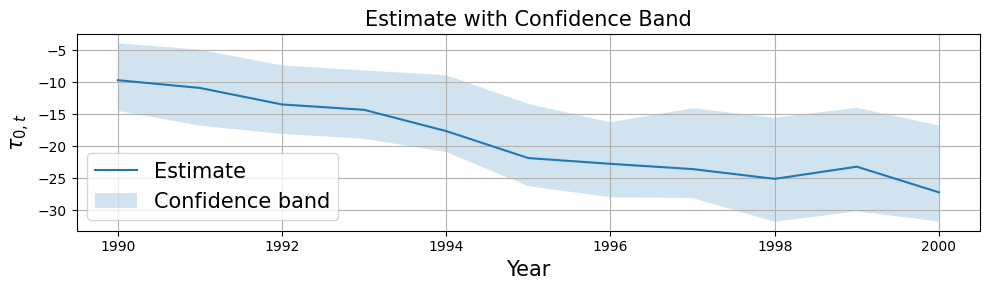

In [32]:
result = np.load("result/tabacco_res.npy")

year_list = [1990 + i for i in range(11)]

plot_method_indices = [0, 1, 2, 3, 4, 6, 7, 8]  # match paper figure panel selection

for j in range(len(result)):
    result_temp = pd.DataFrame(result[j]).round(3)
    result_temp.columns = year_list
    result_temp = result_temp.T
    result_temp.columns = ["Estimate ($\\widehat{\\tau}_{0, t}$)", "Lower bound ($\\underline{\\tau}_{0, t}$)", "Upper bound ($\\overline{\\tau}_{0, t}$)"]
    result_temp = result_temp.T
    print(result_temp.to_latex(float_format="{:.3f}".format))
    
    years = result_temp.columns.astype(int)
    estimate = result_temp.loc[r"Estimate ($\widehat{\tau}_{0, t}$)"].values
    lower = result_temp.loc[r"Lower bound ($\underline{\tau}_{0, t}$)"].values
    upper = result_temp.loc[r"Upper bound ($\overline{\tau}_{0, t}$)"].values

    if j in plot_method_indices:
        # Plot
        plt.figure(figsize=(10, 3))
        plt.plot(years, estimate, label="Estimate")
        plt.fill_between(years, lower, upper, alpha=0.2, label="Confidence band")
        plt.xlabel("Year", fontsize=15)
        plt.ylabel(r"$\tau_{0, t}$", fontsize=15)
        plt.title("Estimate with Confidence Band", fontsize=15)
        plt.legend(fontsize=15)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [36]:
result = np.load("result/tabacco_res.npy")

year_list = [1990 + i for i in range(11)]

plot_method_indices = [0, 1, 2, 3, 4, 6, 7, 8]  # match paper figure panel selection

for j in range(len(result)):
    result_temp = pd.DataFrame(result[j]).round(3)
    result_temp.columns = year_list
    result_temp = result_temp.T
    result_temp.columns = ["Estimate ($\\widehat{\\tau}_{0, t}$)", "Lower bound ($\\underline{\\tau}_{0, t}$)", "Upper bound ($\\overline{\\tau}_{0, t}$)"]
    result_temp = result_temp.T
    print(result_temp.to_latex(float_format="{:.3f}".format))
    
    years = result_temp.columns.astype(int)
    estimate = result_temp.loc[r"Estimate ($\widehat{\tau}_{0, t}$)"].values
    lower = result_temp.loc[r"Lower bound ($\underline{\tau}_{0, t}$)"].values
    upper = result_temp.loc[r"Upper bound ($\overline{\tau}_{0, t}$)"].values

\begin{tabular}{lrrrrrrrrrrr}
\toprule
 & 1990 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 & 1998 & 1999 & 2000 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & -14.348 & -22.565 & -22.348 & -25.688 & -29.688 & -31.646 & -31.870 & -32.007 & -32.452 & -34.963 & -36.109 \\
Lower bound ($\underline{\tau}_{0, t}$) & -16.957 & -26.668 & -26.411 & -30.359 & -35.086 & -37.400 & -37.665 & -37.826 & -38.353 & -41.320 & -42.674 \\
Upper bound ($\overline{\tau}_{0, t}$) & 5.073 & 7.977 & 7.901 & 9.082 & 10.496 & 11.188 & 11.267 & 11.315 & 11.473 & 12.361 & 12.766 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrrrrrrrrrrr}
\toprule
 & 1990 & 1991 & 1992 & 1993 & 1994 & 1995 & 1996 & 1997 & 1998 & 1999 & 2000 \\
\midrule
Estimate ($\widehat{\tau}_{0, t}$) & -14.162 & -22.355 & -22.181 & -25.662 & -29.757 & -31.655 & -31.749 & -32.075 & -32.421 & -34.761 & -35.743 \\
Lower bound ($\underline{\tau}_{0, t}$) & -19.598 & -30.936 & -30.695 & -35.512 & -41.179 & -43.806 & -43.936 & -44.387 & -44.865